In [1]:
import os
from pathlib import Path

# Check downloaded data
for hive in ['hive_01', 'hive_03', 'hive_04']:
    audio_path = Path(f'../data/audio/{hive}')
    sensor_path = Path(f'../data/sensors/{hive}')
    
    flac_files = list(audio_path.rglob('*.flac')) if audio_path.exists() else []
    csv_files  = list(sensor_path.rglob('*.csv'))  if sensor_path.exists() else []
    
    print(f"{hive}: {len(flac_files)} audio files | {len(csv_files)} sensor files")


hive_01: 462 audio files | 0 sensor files
hive_03: 462 audio files | 2 sensor files
hive_04: 393 audio files | 2 sensor files


File: hive_03_20260307_170314.flac
Sample rate : 16000 Hz
Duration    : 1800.0 seconds


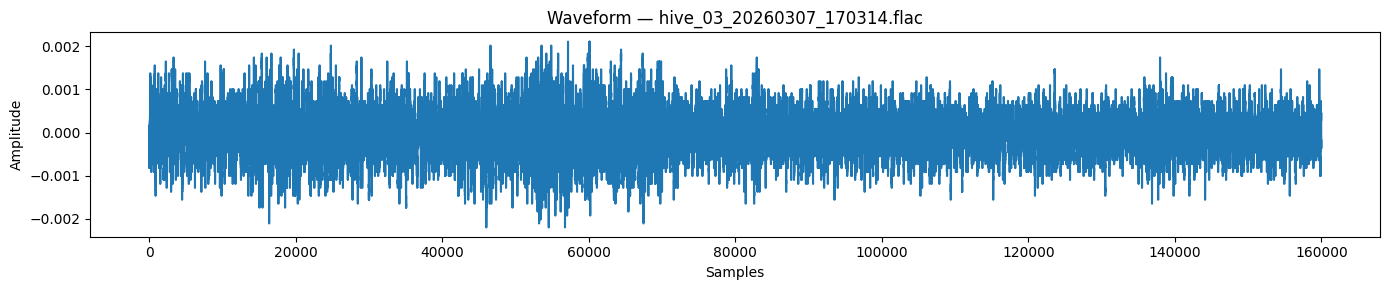

In [2]:
import soundfile as sf
import matplotlib.pyplot as plt

# Load first file from hive_03
first_file = sorted(Path('../data/audio/hive_03').rglob('*.flac'))[0]
print(f"File: {first_file.name}")

y, sr = sf.read(str(first_file))
print(f"Sample rate : {sr} Hz")
print(f"Duration    : {len(y)/sr:.1f} seconds")

# Plot waveform
plt.figure(figsize=(14, 3))
plt.plot(y[:sr*10])
plt.title(f"Waveform — {first_file.name}")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

In [3]:
import numpy as np
import pandas as pd
import soundfile as sf
import librosa
from scipy.signal import butter, sosfilt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

print("All imports OK")

All imports OK


In [4]:
def extract_features(filepath: Path) -> dict:
    """Extract all acoustic features from one .flac file."""
    
    # Load audio
    y, sr = sf.read(str(filepath))
    
    # Bandpass filter 100–2000 Hz (bee signal range)
    sos = butter(6, [100, 2000], btype='band', fs=sr, output='sos')
    y = sosfilt(sos, y)
    
    # Frame settings: 1s windows, 50% overlap
    frame_len = sr        # 16000 samples = 1 second
    hop       = sr // 2   # 8000 samples = 0.5 second
    
    # --- Core spectral features ---
    mfccs     = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13,
                                      n_fft=frame_len, hop_length=hop)
    centroid  = librosa.feature.spectral_centroid(y=y, sr=sr,
                                      n_fft=frame_len, hop_length=hop)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr,
                                      n_fft=frame_len, hop_length=hop)
    rolloff   = librosa.feature.spectral_rolloff(y=y, sr=sr,
                                      n_fft=frame_len, hop_length=hop)
    flatness  = librosa.feature.spectral_flatness(y=y,
                                      n_fft=frame_len, hop_length=hop)
    zcr       = librosa.feature.zero_crossing_rate(y,
                                      frame_length=frame_len, hop_length=hop)
    rms       = librosa.feature.rms(y=y,
                                      frame_length=frame_len, hop_length=hop)
    chroma    = librosa.feature.chroma_stft(y=y, sr=sr,
                                      n_fft=frame_len, hop_length=hop)
    
    # --- Modulation spectrogram (key bee feature) ---
    S = np.abs(librosa.stft(y, n_fft=frame_len, hop_length=hop))
    mod_spec = np.abs(np.fft.rfft(S, axis=1))  # (freq_bins, mod_freqs)
    
    # Modulation energy in bee-relevant 1–30 Hz range
    mod_freqs = np.fft.rfftfreq(S.shape[1], d=hop/sr)
    bee_mask  = (mod_freqs >= 1) & (mod_freqs <= 30)
    
    mod_energy_bee = mod_spec[:, bee_mask].mean() if bee_mask.any() else 0.0
    mod_peak_freq  = (mod_freqs[bee_mask][mod_spec[:, bee_mask]
                     .mean(axis=0).argmax()] if bee_mask.any() else 0.0)
    
    # --- Parse timestamp + hive from filename ---
    # filename format: hive_03_20260307_170314.flac
    stem  = filepath.stem.split('_')
    hive  = f"hive_{stem[1]}"
    ts    = pd.to_datetime(stem[2] + stem[3], format='%Y%m%d%H%M%S')
    
    # --- Build feature dictionary ---
    feat = {
        'timestamp' : ts,
        'hive'      : hive,
        'filename'  : filepath.name,
    }
    
    # MFCCs — mean and std for each of 13 coefficients
    for i in range(13):
        feat[f'mfcc_{i:02d}_mean'] = mfccs[i].mean()
        feat[f'mfcc_{i:02d}_std']  = mfccs[i].std()
    
    # Single spectral features
    feat['centroid_mean']    = centroid.mean()
    feat['centroid_std']     = centroid.std()
    feat['bandwidth_mean']   = bandwidth.mean()
    feat['bandwidth_std']    = bandwidth.std()
    feat['rolloff_mean']     = rolloff.mean()
    feat['flatness_mean']    = flatness.mean()
    feat['flatness_std']     = flatness.std()
    feat['zcr_mean']         = zcr.mean()
    feat['zcr_std']          = zcr.std()
    feat['rms_mean']         = rms.mean()
    feat['rms_std']          = rms.std()
    feat['chroma_mean']      = chroma.mean()
    feat['chroma_std']       = chroma.std()
    feat['mod_energy_bee']   = mod_energy_bee
    feat['mod_peak_freq']    = mod_peak_freq
    
    return feat

print("Function defined OK")

Function defined OK


In [5]:
# Collect all flac files from our 3 hives
hives_to_process = ['hive_01', 'hive_03', 'hive_04']
all_files = []
for hive in hives_to_process:
    files = sorted(Path(f'../data/audio/{hive}').rglob('*.flac'))
    all_files.extend(files)

print(f"Total files to process: {len(all_files)}")

# Process all files
results = []
failed  = []

for i, filepath in enumerate(all_files):
    try:
        feat = extract_features(filepath)
        results.append(feat)
        
        # Progress update every 50 files
        if (i + 1) % 50 == 0:
            print(f"  [{i+1}/{len(all_files)}] {filepath.parent.parent.name} — {filepath.name}")
    
    except Exception as e:
        failed.append({'file': filepath.name, 'error': str(e)})

print(f"\nDone! Extracted: {len(results)} | Failed: {len(failed)}")

# Save immediately — never want to rerun this
df = pd.DataFrame(results).sort_values('timestamp').reset_index(drop=True)
df.to_csv('../data/features_all_hives.csv', index=False)
print(f"Saved to data/features_all_hives.csv")
print(df.head())

Total files to process: 1317
  [50/1317] 03 — hive_01_20260308_173621.flac
  [100/1317] 03 — hive_01_20260309_183935.flac
  [150/1317] 03 — hive_01_20260310_194239.flac
  [200/1317] 03 — hive_01_20260311_205324.flac
  [250/1317] 03 — hive_01_20260312_215848.flac
  [300/1317] 03 — hive_01_20260313_225952.flac
  [350/1317] 03 — hive_01_20260315_000340.flac
  [400/1317] 03 — hive_01_20260316_010936.flac
  [450/1317] 03 — hive_01_20260317_021102.flac
  [500/1317] 03 — hive_03_20260308_113546.flac
  [550/1317] 03 — hive_03_20260309_124145.flac
  [600/1317] 03 — hive_03_20260310_134304.flac
  [650/1317] 03 — hive_03_20260311_145116.flac
  [700/1317] 03 — hive_03_20260312_155506.flac
  [750/1317] 03 — hive_03_20260313_165909.flac
  [800/1317] 03 — hive_03_20260314_180329.flac
  [850/1317] 03 — hive_03_20260315_190529.flac
  [900/1317] 03 — hive_03_20260316_200810.flac
  [950/1317] 03 — hive_04_20260309_160322.flac
  [1000/1317] 03 — hive_04_20260310_170611.flac
  [1050/1317] 03 — hive_04_2026

In [6]:
df = pd.read_csv('../data/features_all_hives.csv', parse_dates=['timestamp'])

print("Shape:", df.shape)
print("\nHive counts:")
print(df['hive'].value_counts())
print("\nDate range:")
print(df['timestamp'].min(), "→", df['timestamp'].max())
print("\nSample of key features:")
print(df[['timestamp','hive','rms_mean','centroid_mean','mod_energy_bee']].head(10))

Shape: (1317, 44)

Hive counts:
hive
hive_03    462
hive_01    462
hive_04    393
Name: count, dtype: int64

Date range:
2026-03-07 17:03:14 → 2026-03-17 08:12:06

Sample of key features:
            timestamp     hive  rms_mean  centroid_mean  mod_energy_bee
0 2026-03-07 17:03:14  hive_03  0.000397     546.599748             0.0
1 2026-03-07 17:03:20  hive_04  0.000576     669.695128             0.0
2 2026-03-07 17:03:23  hive_01  0.000560     550.703931             0.0
3 2026-03-07 17:33:14  hive_03  0.000257     561.568764             0.0
4 2026-03-07 17:33:20  hive_04  0.000146     217.454287             0.0
5 2026-03-07 17:33:23  hive_01  0.000444     569.788266             0.0
6 2026-03-07 18:03:14  hive_03  0.000252     565.333711             0.0
7 2026-03-07 18:03:23  hive_01  0.000429     566.759487             0.0
8 2026-03-07 18:33:14  hive_03  0.000228     560.016084             0.0
9 2026-03-07 18:33:23  hive_01  0.000404     571.756185             0.0


Variance explained per component:
  PC1: 0.336  (cumulative: 0.336)
  PC2: 0.211  (cumulative: 0.547)
  PC3: 0.115  (cumulative: 0.663)
  PC4: 0.102  (cumulative: 0.765)
  PC5: 0.060  (cumulative: 0.824)
  PC6: 0.033  (cumulative: 0.858)
  PC7: 0.024  (cumulative: 0.882)
  PC8: 0.019  (cumulative: 0.901)
  PC9: 0.017  (cumulative: 0.918)
  PC10: 0.013  (cumulative: 0.931)

Cluster counts:
cluster
1    1030
0     281
2       6
Name: count, dtype: int64


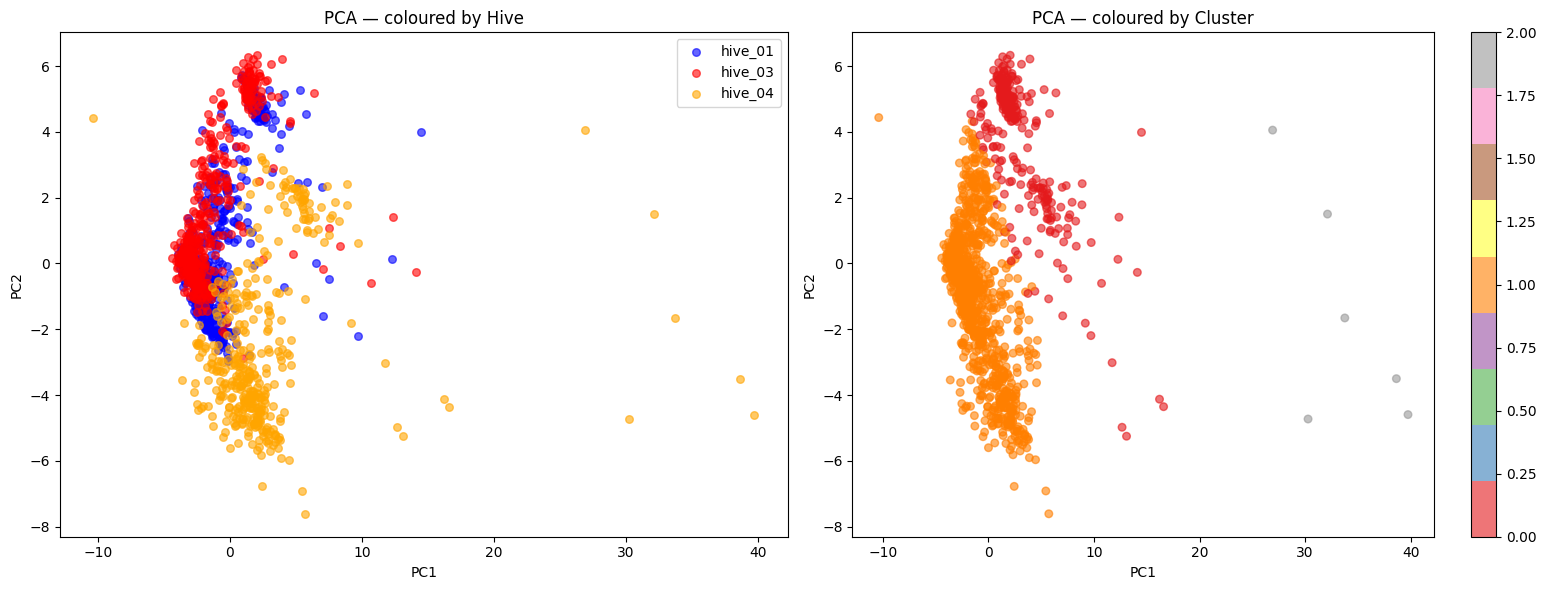

Saved to report/pca_clusters.png


In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Load features
df = pd.read_csv('../data/features_all_hives.csv', parse_dates=['timestamp'])

# Select only numeric feature columns
feature_cols = [c for c in df.columns 
                if c not in ['timestamp', 'hive', 'filename']]

X = df[feature_cols].fillna(0).values

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Variance explained per component:")
for i, v in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {v:.3f}  (cumulative: {pca.explained_variance_ratio_[:i+1].sum():.3f})")

# Store PCA coords
df['pca_1'] = X_pca[:, 0]
df['pca_2'] = X_pca[:, 1]

# KMeans
km = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(X_pca)

print("\nCluster counts:")
print(df['cluster'].value_counts())

# Two plots side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: colour by hive
colors_hive = {'hive_01': 'blue', 'hive_03': 'red', 'hive_04': 'orange'}
for hive, grp in df.groupby('hive'):
    axes[0].scatter(grp['pca_1'], grp['pca_2'],
                    c=colors_hive[hive], label=hive, alpha=0.6, s=30)
axes[0].set_title('PCA — coloured by Hive')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

# Right: colour by cluster
scatter = axes[1].scatter(df['pca_1'], df['pca_2'],
                           c=df['cluster'], cmap='Set1', alpha=0.6, s=30)
axes[1].set_title('PCA — coloured by Cluster')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.colorbar(scatter, ax=axes[1])

plt.tight_layout()
plt.savefig('../report/pca_clusters.png', dpi=150)
plt.show()
print("Saved to report/pca_clusters.png")


hive_03 cluster changes:
  2026-03-07 17:03 → Cluster 0
  2026-03-07 17:33 → Cluster 1
  2026-03-08 03:03 → Cluster 0
  2026-03-08 03:33 → Cluster 1
  2026-03-08 04:03 → Cluster 0
  2026-03-08 05:04 → Cluster 1
  2026-03-08 07:34 → Cluster 0
  2026-03-08 09:35 → Cluster 1
  2026-03-08 10:35 → Cluster 0
  2026-03-08 11:05 → Cluster 1
  2026-03-08 11:35 → Cluster 0
  2026-03-08 12:05 → Cluster 1
  2026-03-08 13:05 → Cluster 0
  2026-03-08 13:36 → Cluster 1
  2026-03-08 14:06 → Cluster 0
  2026-03-08 15:37 → Cluster 1
  2026-03-08 16:37 → Cluster 0
  2026-03-08 17:07 → Cluster 1
  2026-03-08 18:07 → Cluster 0
  2026-03-08 19:08 → Cluster 1
  2026-03-08 19:38 → Cluster 0
  2026-03-08 22:09 → Cluster 1
  2026-03-08 22:39 → Cluster 0
  2026-03-08 23:10 → Cluster 1
  2026-03-09 01:10 → Cluster 0
  2026-03-09 01:40 → Cluster 1
  2026-03-09 03:10 → Cluster 0
  2026-03-09 03:40 → Cluster 1
  2026-03-09 04:40 → Cluster 0
  2026-03-09 05:11 → Cluster 1
  2026-03-09 05:41 → Cluster 0
  2026-03-09 

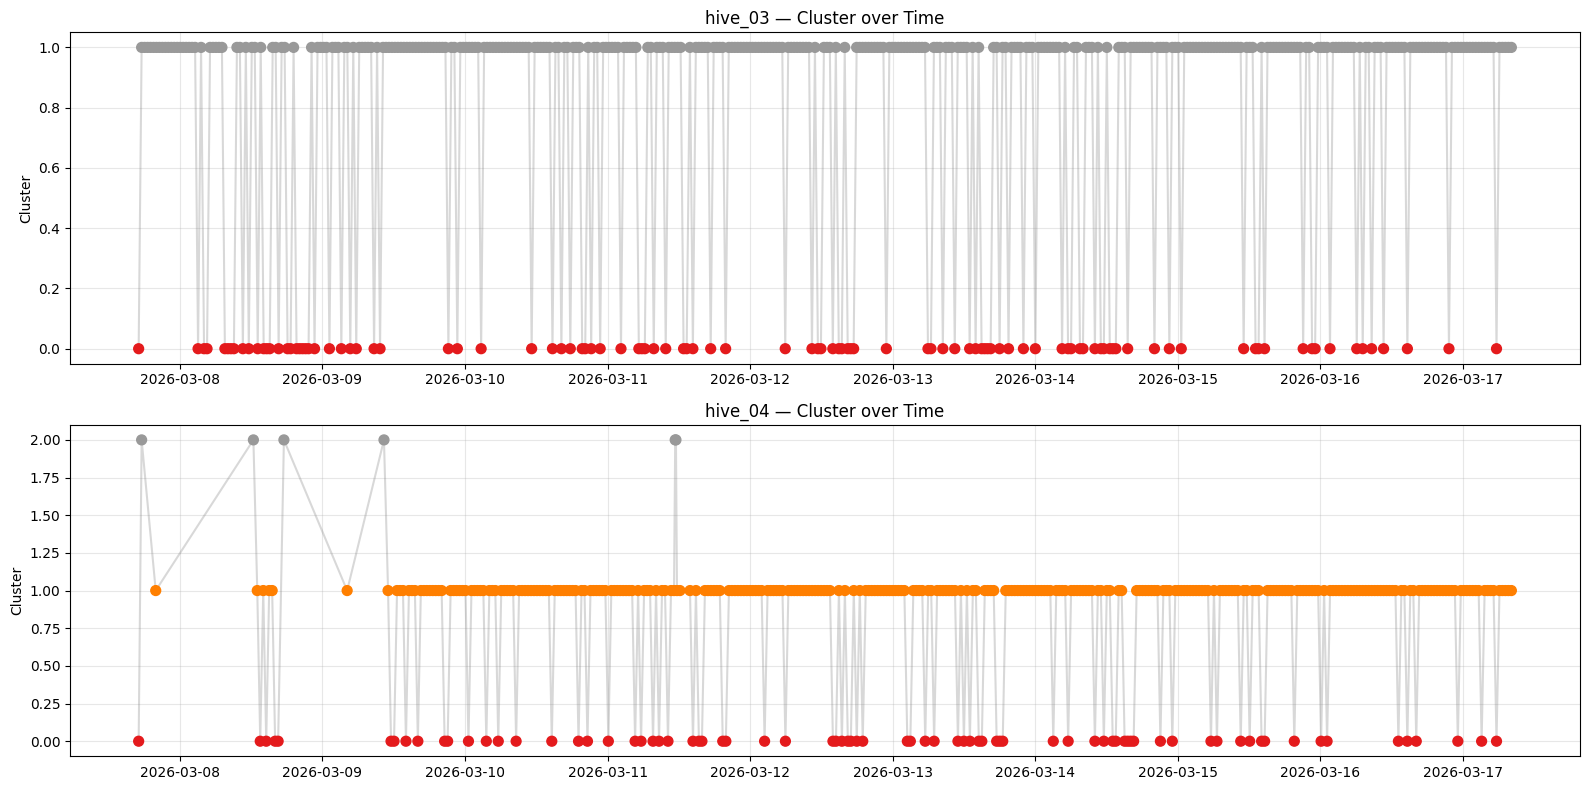

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

for idx, hive in enumerate(['hive_03', 'hive_04']):
    hive_df = df[df['hive'] == hive].sort_values('timestamp')
    
    axes[idx].scatter(hive_df['timestamp'], hive_df['cluster'],
                      c=hive_df['cluster'], cmap='Set1', s=50, zorder=3)
    axes[idx].plot(hive_df['timestamp'], hive_df['cluster'],
                   alpha=0.3, color='gray')
    axes[idx].set_title(f'{hive} — Cluster over Time')
    axes[idx].set_ylabel('Cluster')
    axes[idx].grid(True, alpha=0.3)
    
    print(f"\n{hive} cluster changes:")
    prev = None
    for _, row in hive_df.iterrows():
        if row['cluster'] != prev:
            print(f"  {row['timestamp'].strftime('%Y-%m-%d %H:%M')} → Cluster {row['cluster']}")
            prev = row['cluster']

plt.tight_layout()
plt.savefig('../report/cluster_timeline.png', dpi=150)
plt.show()

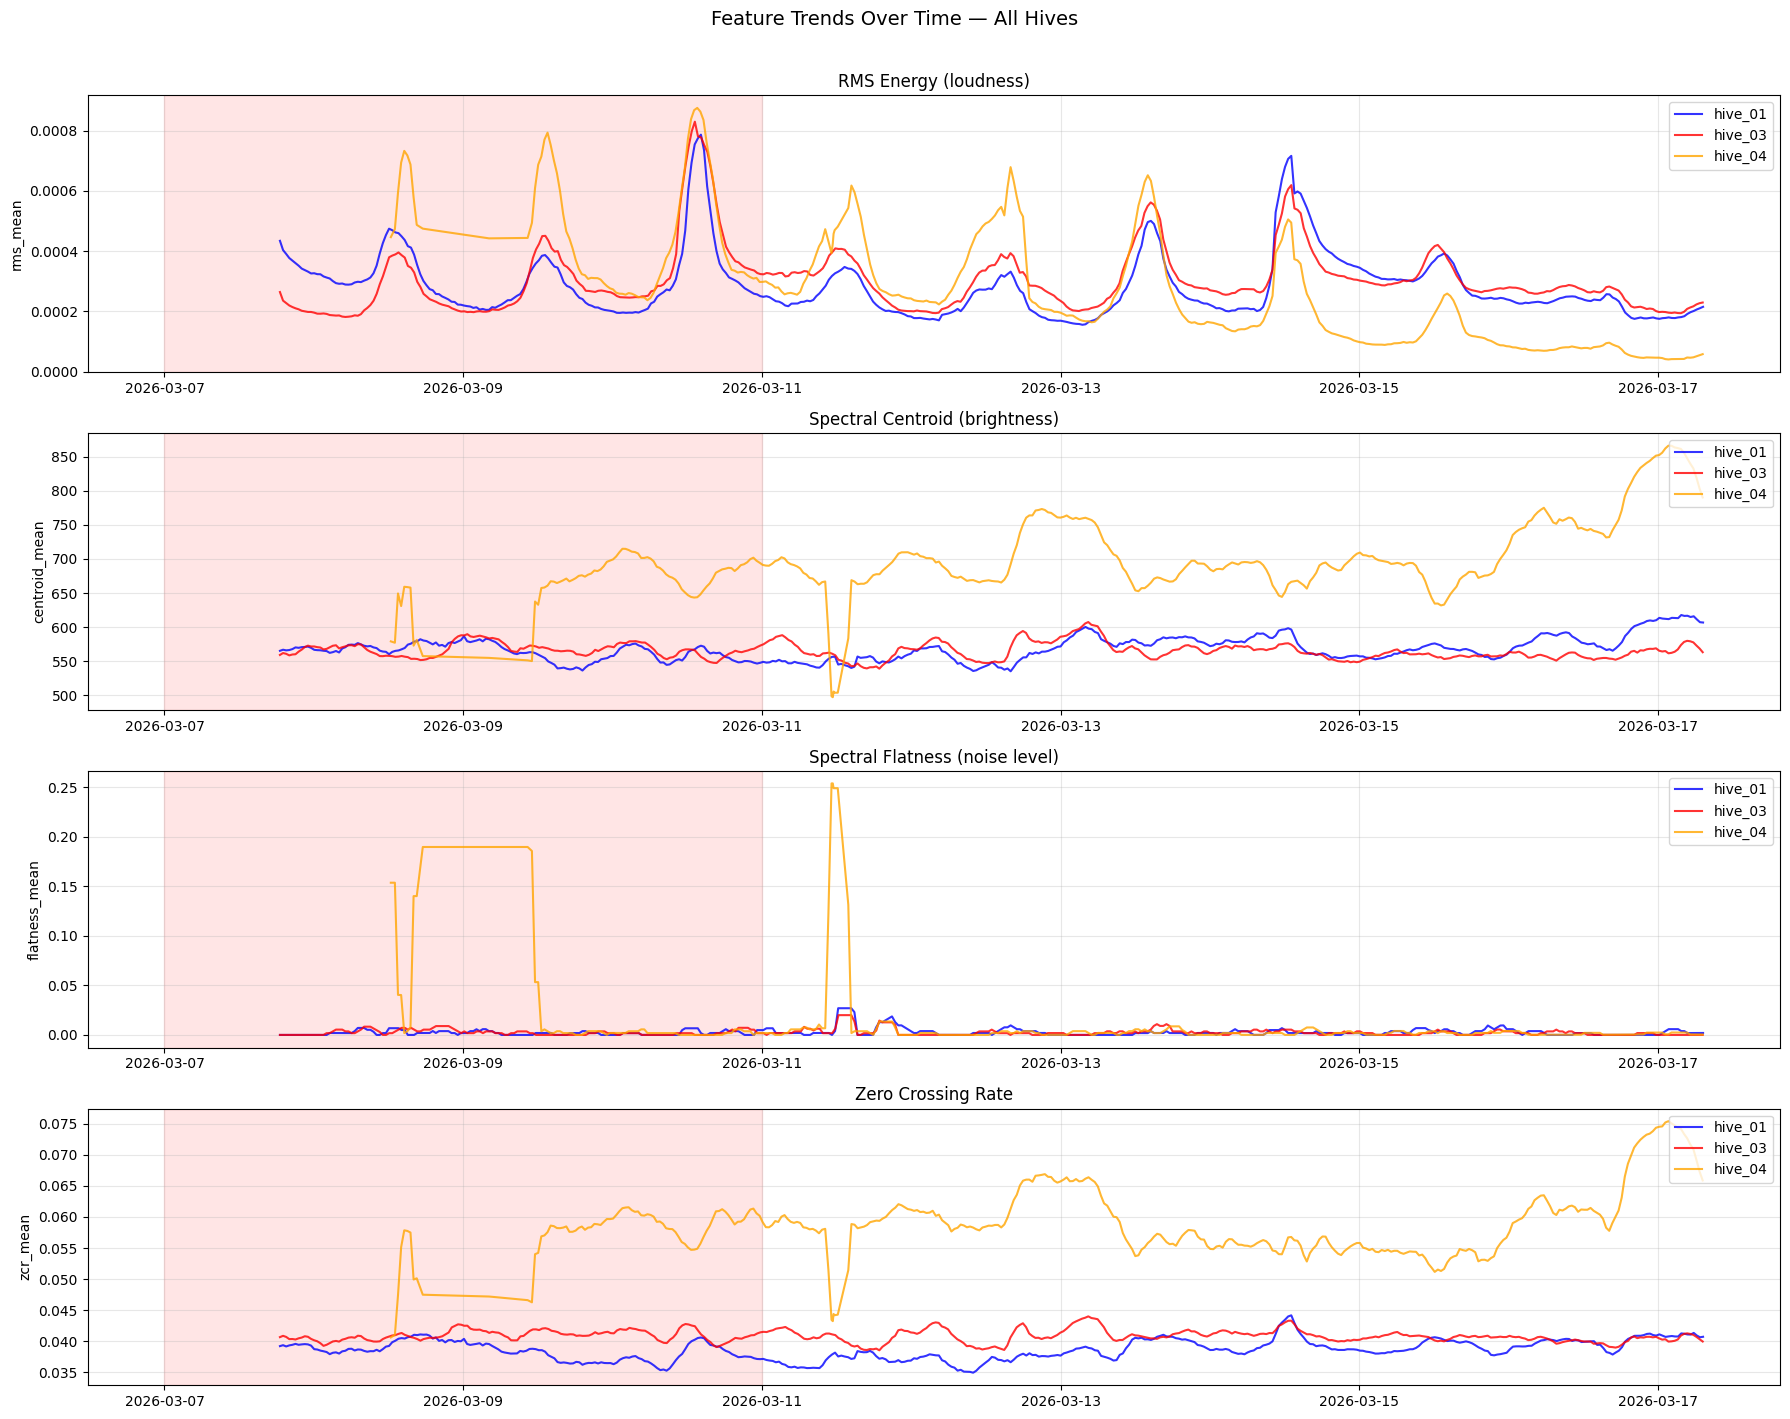

In [9]:
fig, axes = plt.subplots(4, 1, figsize=(18, 14))

features_to_plot = ['rms_mean', 'centroid_mean', 'flatness_mean', 'zcr_mean']
titles = ['RMS Energy (loudness)', 'Spectral Centroid (brightness)', 
          'Spectral Flatness (noise level)', 'Zero Crossing Rate']
colors = {'hive_01': 'blue', 'hive_03': 'red', 'hive_04': 'orange'}

for ax, feat, title in zip(axes, features_to_plot, titles):
    for hive, grp in df.groupby('hive'):
        grp_sorted = grp.sort_values('timestamp')
        # Rolling average to smooth out day/night noise
        grp_sorted[f'{feat}_smooth'] = grp_sorted[feat].rolling(6, center=True).mean()
        ax.plot(grp_sorted['timestamp'], grp_sorted[f'{feat}_smooth'],
                color=colors[hive], label=hive, linewidth=1.5, alpha=0.8)
    ax.set_title(title)
    ax.set_ylabel(feat)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    # Mark the suspected queenless window
    ax.axvspan(pd.Timestamp('2026-03-07'), pd.Timestamp('2026-03-11'),
               alpha=0.1, color='red', label='Suspected queenless window')

plt.suptitle('Feature Trends Over Time — All Hives', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../report/feature_trends.png', dpi=150, bbox_inches='tight')
plt.show()

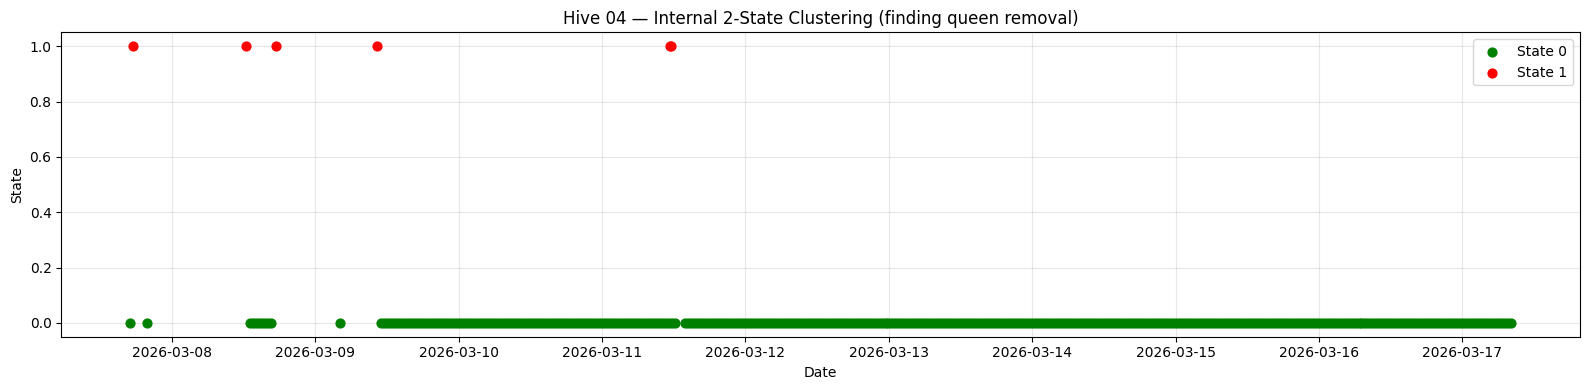

Hive 04 state changes:
  2026-03-07 17:03 → State 0
  2026-03-07 17:33 → State 1
  2026-03-07 19:55 → State 0
  2026-03-08 12:22 → State 1
  2026-03-08 13:01 → State 0
  2026-03-08 17:30 → State 1
  2026-03-09 04:09 → State 0
  2026-03-09 10:21 → State 1
  2026-03-09 11:02 → State 0
  2026-03-11 11:22 → State 1
  2026-03-11 11:40 → State 0

Daily state summary for hive_04:
            dominant  state0_count  state1_count
date                                            
2026-03-07         0             2             1
2026-03-08         0             8             2
2026-03-09         0            27             1
2026-03-10         0            48             0
2026-03-11         0            46             2
2026-03-12         0            48             0
2026-03-13         0            47             0
2026-03-14         0            48             0
2026-03-15         0            48             0
2026-03-16         0            48             0
2026-03-17         0            17  

In [11]:
# Focus on hive_04 alone — cluster internally
hive4 = df[df['hive'] == 'hive_04'].sort_values('timestamp').copy()

X4 = hive4[feature_cols].fillna(0).values
X4_scaled = StandardScaler().fit_transform(X4)
pca4 = PCA(n_components=5, random_state=42)
X4_pca = pca4.fit_transform(X4_scaled)

km4 = KMeans(n_clusters=2, random_state=42, n_init=10)
hive4['state'] = km4.fit_predict(X4_pca)

# Plot hive_04 state over time
fig, ax = plt.subplots(figsize=(16, 4))
colors_state = {0: 'green', 1: 'red'}
for state, grp in hive4.groupby('state'):
    label = f'State {state}'
    ax.scatter(grp['timestamp'], grp['state'],
               color=colors_state[state], label=label, s=40, zorder=3)

ax.set_title('Hive 04 — Internal 2-State Clustering (finding queen removal)')
ax.set_ylabel('State')
ax.set_xlabel('Date')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../report/hive04_states.png', dpi=150)
plt.show()

# Print exact transition dates
print("Hive 04 state changes:")
prev = None
for _, row in hive4.iterrows():
    if row['state'] != prev:
        print(f"  {row['timestamp'].strftime('%Y-%m-%d %H:%M')} → State {int(row['state'])}")
        prev = row['state']

# Summary: which days are predominantly each state
print("\nDaily state summary for hive_04:")
hive4['date'] = hive4['timestamp'].dt.date
daily = hive4.groupby('date')['state'].agg(
    dominant=lambda x: x.mode()[0],
    state0_count=lambda x: (x==0).sum(),
    state1_count=lambda x: (x==1).sum()
)
print(daily)

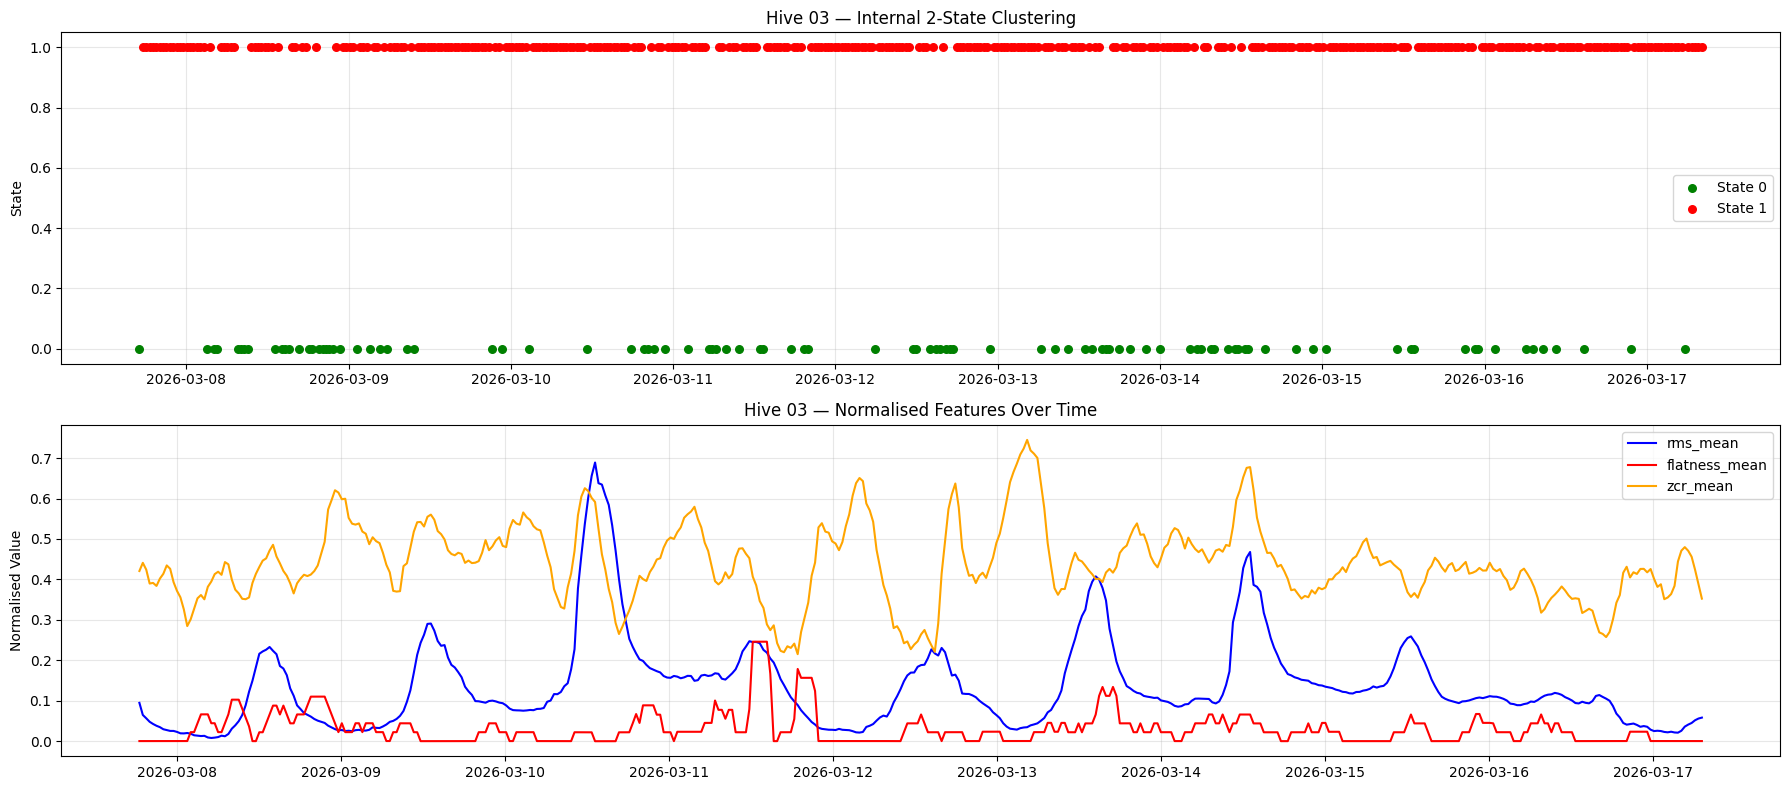

Daily state summary for hive_03:
            dominant  state0_count  state1_count
date                                            
2026-03-07         1             1            13
2026-03-08         1            20            28
2026-03-09         1             8            40
2026-03-10         1             7            41
2026-03-11         1            11            37
2026-03-12         1            10            38
2026-03-13         1            11            36
2026-03-14         1            14            34
2026-03-15         1             7            41
2026-03-16         1             7            41
2026-03-17         1             1            16


In [12]:
# Internal 2-state clustering for hive_03
hive3 = df[df['hive'] == 'hive_03'].sort_values('timestamp').copy()

X3 = hive3[feature_cols].fillna(0).values
X3_scaled = StandardScaler().fit_transform(X3)
pca3 = PCA(n_components=5, random_state=42)
X3_pca = pca3.fit_transform(X3_scaled)

km3 = KMeans(n_clusters=2, random_state=42, n_init=10)
hive3['state'] = km3.fit_predict(X3_pca)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(18, 8))

# State over time
colors_state = {0: 'green', 1: 'red'}
for state, grp in hive3.groupby('state'):
    axes[0].scatter(grp['timestamp'], grp['state'],
                    color=colors_state[state], s=30, 
                    label=f'State {state}', zorder=3)
axes[0].set_title('Hive 03 — Internal 2-State Clustering')
axes[0].set_ylabel('State')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Key features for hive_03 over time
hive3_sorted = hive3.sort_values('timestamp')
for feat, color in [('rms_mean','blue'), ('flatness_mean','red'), ('zcr_mean','orange')]:
    norm = (hive3_sorted[feat] - hive3_sorted[feat].min()) / \
           (hive3_sorted[feat].max() - hive3_sorted[feat].min() + 1e-9)
    axes[1].plot(hive3_sorted['timestamp'], norm.rolling(6, center=True).mean(),
                 label=feat, color=color, linewidth=1.5)

axes[1].set_title('Hive 03 — Normalised Features Over Time')
axes[1].set_ylabel('Normalised Value')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../report/hive03_states.png', dpi=150)
plt.show()

# Daily summary
print("Daily state summary for hive_03:")
hive3['date'] = hive3['timestamp'].dt.date
daily3 = hive3.groupby('date')['state'].agg(
    dominant=lambda x: x.mode()[0],
    state0_count=lambda x: (x==0).sum(),
    state1_count=lambda x: (x==1).sum()
)
print(daily3)

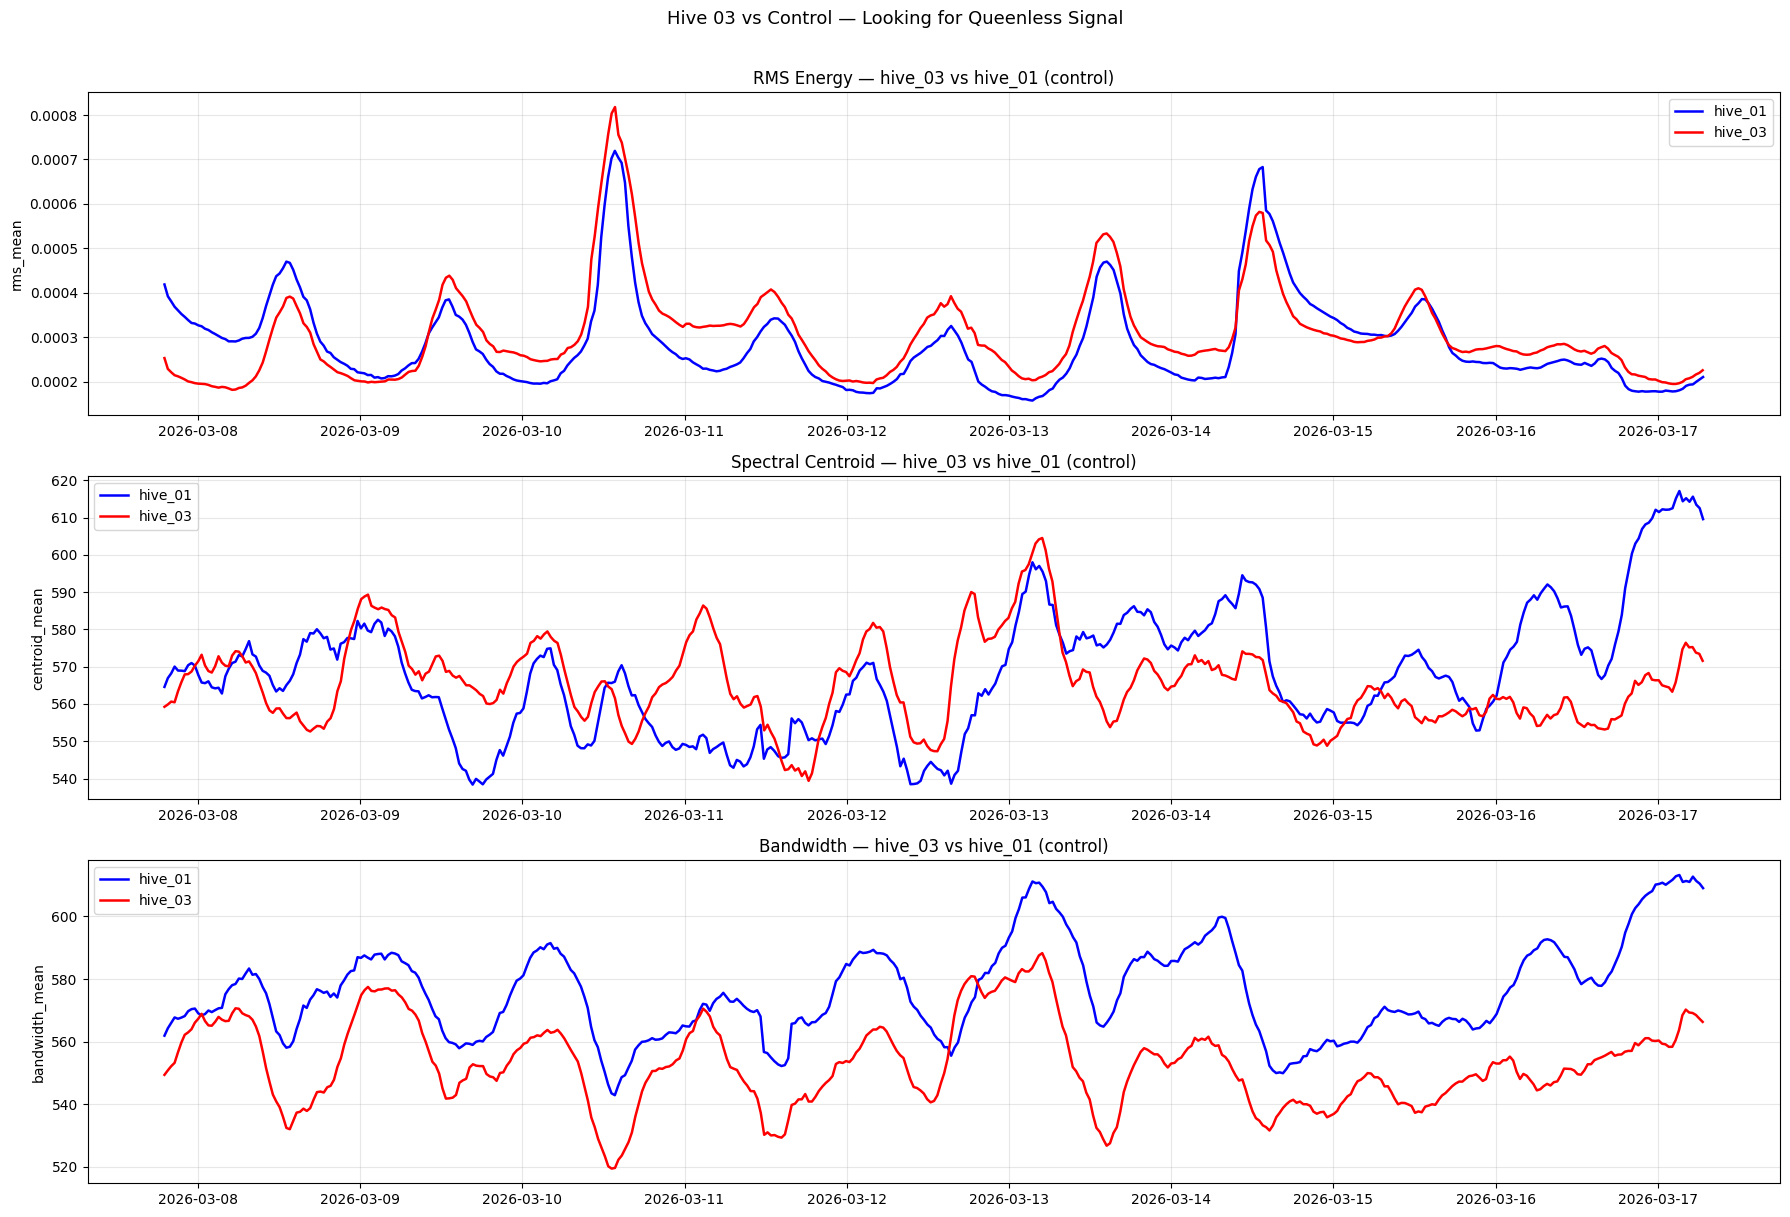

In [13]:
# Compare hive_03 directly against control hive_01
fig, axes = plt.subplots(3, 1, figsize=(18, 12))

key_feats = ['rms_mean', 'centroid_mean', 'bandwidth_mean']
titles    = ['RMS Energy', 'Spectral Centroid', 'Bandwidth']
colors    = {'hive_01': 'blue', 'hive_03': 'red'}

for ax, feat, title in zip(axes, key_feats, titles):
    for hive in ['hive_01', 'hive_03']:
        grp = df[df['hive'] == hive].sort_values('timestamp')
        smoothed = grp[feat].rolling(8, center=True).mean()
        ax.plot(grp['timestamp'], smoothed,
                color=colors[hive], label=hive, linewidth=1.8)
    ax.set_title(f'{title} — hive_03 vs hive_01 (control)')
    ax.set_ylabel(feat)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Hive 03 vs Control — Looking for Queenless Signal', 
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../report/hive03_vs_control.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
from pathlib import Path

BASE = Path('C:/Users/Hashim Ali/Desktop/HiveNavigator')

# Check features file
print("Features CSV:", (BASE / 'data' / 'features_all_hives.csv').exists())

# Check sensor files
for hive in ['hive_03', 'hive_04']:
    files = list((BASE / 'data' / 'sensors' / hive).rglob('*sensors*.csv'))
    print(f"{hive} sensor files: {files}")

Features CSV: True
hive_03 sensor files: [WindowsPath('C:/Users/Hashim Ali/Desktop/HiveNavigator/data/sensors/hive_03/03/hive_03_sensors.csv')]
hive_04 sensor files: [WindowsPath('C:/Users/Hashim Ali/Desktop/HiveNavigator/data/sensors/hive_04/03/hive_04_sensors.csv')]
